In [216]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import joblib

In [217]:
# ============================================
# 2. LOAD DATASET
# ============================================

df=pd.read_excel('dataset.xlsx')
df

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (1440, 3)

Columns:
['title', 'rating', 'body']


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [218]:
# Check column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [219]:
# ============================================
# 3. BASIC DATA INSPECTION
# ============================================

print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nFirst 5 rows:")
display(df.head())

Shape: (1440, 3)

Missing values:
title     0
rating    0
body      0
dtype: int64

Duplicate rows: 0

First 5 rows:


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [220]:
df['text']=(df['title'].fillna("") + " " + df['body'].fillna(""))

In [221]:
# ============================================
# 4. KEEP REQUIRED COLUMNS
# ============================================

df = df[["text", "rating","body"]].copy()

df.head()

,text,rating,body
0,Horrible product Very disappointed with the ov...,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel Camera...,3,Camera quality is low
2,"Overall Got the mobile on the launch date,Batt...",4,"Got the mobile on the launch date,Battery must..."
3,A big no from me 1. It doesn't work with 5.0GH...,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else Not worth buying...,1,"Not worth buying....faulty software, poor disp..."


In [222]:
# ============================================
# 5. HANDLE MISSING VALUES
# ============================================

print("Missing text:", df["body"].isnull().sum())
print("Missing rating:", df["rating"].isnull().sum())

df = df.dropna(subset=["text", "rating"]).copy()

print("\nShape after removing missing values:", df.shape)

Missing text: 0
Missing rating: 0

Shape after removing missing values: (1440, 3)


In [223]:
# ============================================
# 6. RATING DISTRIBUTION
# ============================================

print(df["rating"].value_counts().sort_index())

rating
1    386
2    126
3    199
4    310
5    419
Name: count, dtype: int64


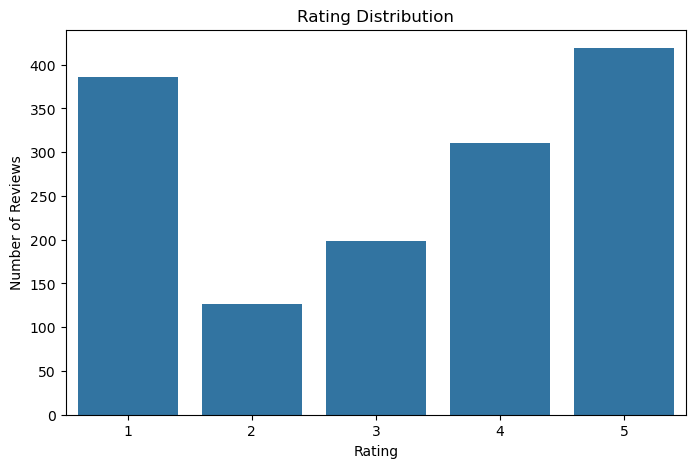

In [224]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="rating"
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [225]:
# ============================================
# 7. CREATE 3-CLASS SENTIMENT
# ============================================

def create_sentiment(rating):
    
    if rating <= 2:
        return "negative"
    
    elif rating == 3:
        return "neutral"
    
    else:
        return "positive"


df["sentiment"] = df["rating"].apply(create_sentiment)

print(df["sentiment"].value_counts())

sentiment
positive    729
negative    512
neutral     199
Name: count, dtype: int64


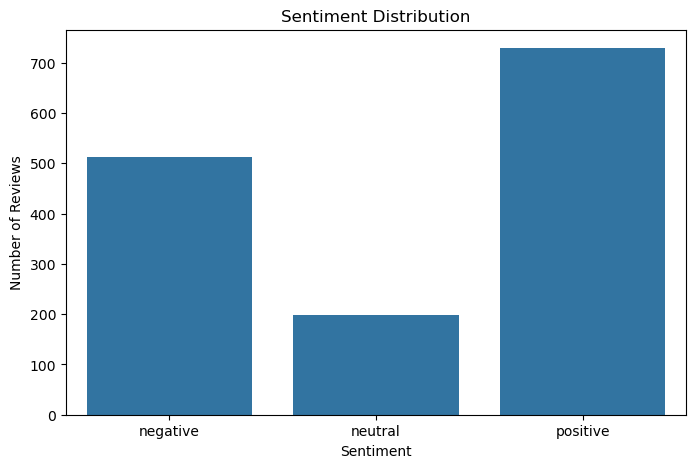

In [226]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sentiment",
    order=["negative", "neutral", "positive"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [227]:
# ============================================
# 8. TEXT LENGTH
# ============================================

df["text_length"] = df["text"].astype(str).apply(len)

df["word_count"] = (
    df["text"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print("Text length statistics:")
display(df["text_length"].describe())

print("\nWord count statistics:")
display(df["word_count"].describe())

Text length statistics:


count    1440.000000
mean      333.381944
std       229.116704
min         9.000000
25%       198.000000
50%       277.000000
75%       395.000000
max      2536.000000
Name: text_length, dtype: float64


Word count statistics:


count    1440.000000
mean       58.257639
std        39.896874
min         2.000000
25%        34.000000
50%        49.000000
75%        70.000000
max       391.000000
Name: word_count, dtype: float64

In [228]:
# ============================================
# 9. TEXT LENGTH BY SENTIMENT
# ============================================

display(
    df.groupby("sentiment")["text_length"]
      .describe()
)

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,512.0,331.185547,195.195538,27.0,210.75,291.5,394.0,1803.0
neutral,199.0,352.919598,303.700184,41.0,184.50,261.0,438.5,2536.0
positive,729.0,329.591221,227.620787,9.0,191.00,274.0,391.0,1910.0


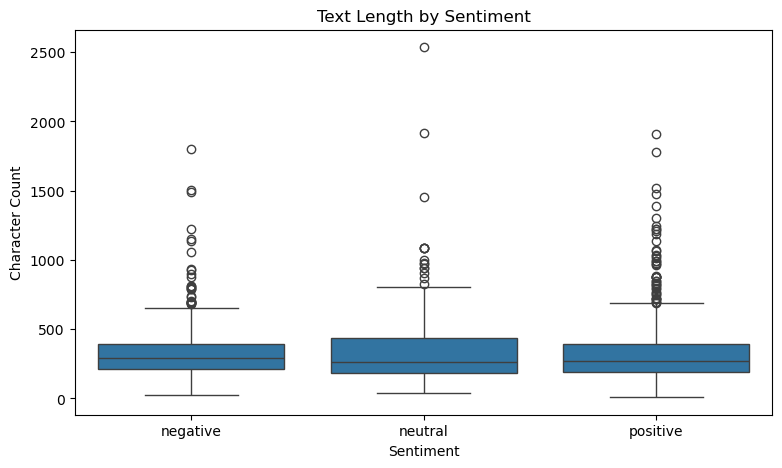

In [229]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="text_length",
    order=["negative", "neutral", "positive"]
)

plt.title("Text Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Character Count")

plt.show()

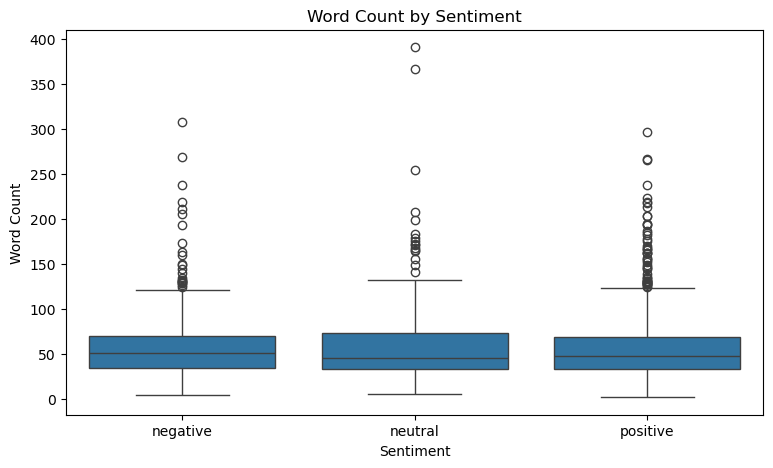

In [230]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="word_count",
    order=["negative", "neutral", "positive"]
)

plt.title("Word Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")

plt.show()

In [231]:
# ============================================
# 11. NOISE CHECK
# ============================================

def count_pattern(pattern, texts):
    return sum(
        bool(re.search(pattern, str(text), flags=re.IGNORECASE))
        for text in texts
    )


url_count = count_pattern(
    r"https?://\S+|www\.\S+",
    df["text"]
)

html_count = count_pattern(
    r"<[^>]+>",
    df["text"]
)

email_count = count_pattern(
    r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
    df["text"]
)

print("Reviews containing URLs:", url_count)
print("Reviews containing HTML:", html_count)
print("Reviews containing emails:", email_count)

Reviews containing URLs: 2
Reviews containing HTML: 1
Reviews containing emails: 0


In [232]:
# ============================================
# 12. OPTIONAL LANGUAGE INVESTIGATION
# ============================================

from langdetect import detect

def detect_language(text):
    try:
        return detect(str(text))
    except:
        return "unknown"


df["detected_language"] = df["text"].apply(detect_language)

print(
    df["detected_language"]
    .value_counts()
)

detected_language
en    1413
hi      11
id       5
ca       3
af       3
lv       1
ml       1
de       1
so       1
no       1
Name: count, dtype: int64


In [233]:
df.drop(columns=["detected_language"], inplace=True)

In [234]:
# ============================================
# 13. LIGHT TEXT PREPROCESSING
# ============================================

def preprocess_text(text):
    
    text = str(text)
    
    # Remove HTML
    text = re.sub(
        r"<[^>]+>",
        " ",
        text
    )
    
    # Replace URLs with special token
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " URL ",
        text,
        flags=re.IGNORECASE
    )
    
    # Normalize whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )
    
    # Lowercase
    text = text.lower()
    
    # Remove leading/trailing spaces
    text = text.strip()
    
    return text


df["processed_text"] = df["text"].apply(preprocess_text)

df[["text", "processed_text"]].head()

,text,processed_text
0,Horrible product Very disappointed with the ov...,horrible product very disappointed with the ov...
1,Camera quality is not like 48 megapixel Camera...,camera quality is not like 48 megapixel camera...
2,"Overall Got the mobile on the launch date,Batt...","overall got the mobile on the launch date,batt..."
3,A big no from me 1. It doesn't work with 5.0GH...,a big no from me 1. it doesn't work with 5.0gh...
4,Put your money somewhere else Not worth buying...,put your money somewhere else not worth buying...


In [235]:
for i in range(5):
    
    print("ORIGINAL:")
    print(df.iloc[i]["text"])
    
    print("\nPROCESSED:")
    print(df.iloc[i]["processed_text"])
    
    print("\n" + "=" * 80 + "\n")

ORIGINAL:
Horrible product Very disappointed with the overall performance from Samsung

PROCESSED:
horrible product very disappointed with the overall performance from samsung


ORIGINAL:
Camera quality is not like 48 megapixel Camera quality is low

PROCESSED:
camera quality is not like 48 megapixel camera quality is low


ORIGINAL:
Overall Got the mobile on the launch date,Battery must be appreciatedCamera is just averageMobile performance is above average90hz refresh rate? If u r buying the mobile for this feature then I'm afraid u may get disappointed, it's just normal.The USB cable is too small in lengthIt's a good mobile in this budget, there are no returns for this,  only replacement is available, hence choose wisely before buying

PROCESSED:
overall got the mobile on the launch date,battery must be appreciatedcamera is just averagemobile performance is above average90hz refresh rate? if u r buying the mobile for this feature then i'm afraid u may get disappointed, it's just nor

In [236]:
# ============================================
# 15. WORD FREQUENCY
# ============================================

def get_words(texts):
    
    words = []
    
    for text in texts:
        tokens = re.findall(
            r"\b\w+\b",
            str(text).lower(),
            flags=re.UNICODE
        )
        
        words.extend(tokens)
    
    return Counter(words)

In [237]:
positive_words = get_words(
    df[df["sentiment"] == "positive"]["processed_text"]
)

print("Positive words:")
print(positive_words.most_common(20))

Positive words:
[('is', 1740), ('the', 1216), ('good', 1074), ('phone', 978), ('for', 943), ('and', 934), ('it', 933), ('this', 758), ('a', 698), ('i', 638), ('battery', 596), ('camera', 594), ('to', 588), ('in', 525), ('not', 460), ('with', 424), ('but', 404), ('of', 389), ('quality', 346), ('price', 338)]


In [238]:
negative_words = get_words(
    df[df["sentiment"] == "negative"]["processed_text"]
)

print("Negative words:")
print(negative_words.most_common(20))

Negative words:
[('is', 948), ('the', 732), ('phone', 642), ('not', 636), ('i', 599), ('and', 591), ('this', 572), ('to', 536), ('it', 474), ('in', 388), ('samsung', 377), ('a', 340), ('for', 332), ('of', 330), ('t', 319), ('very', 318), ('camera', 296), ('mobile', 290), ('quality', 250), ('product', 224)]


In [239]:
neutral_words = get_words(
    df[df["sentiment"] == "neutral"]["processed_text"]
)

print("Neutral words:")
print(neutral_words.most_common(20))

Neutral words:
[('is', 480), ('the', 344), ('not', 297), ('phone', 259), ('and', 232), ('to', 215), ('good', 213), ('i', 213), ('this', 212), ('it', 211), ('camera', 184), ('for', 181), ('a', 169), ('in', 165), ('but', 140), ('of', 130), ('with', 126), ('quality', 123), ('battery', 120), ('mobile', 105)]


In [240]:
# ============================================
# 16. FEATURES AND TARGET
# ============================================

X = df["processed_text"]

y = df["sentiment"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClasses:")
print(y.value_counts())

X shape: (1440,)
y shape: (1440,)

Classes:
sentiment
positive    729
negative    512
neutral     199
Name: count, dtype: int64


In [241]:
# ============================================
# 17. TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training samples: 1152
Testing samples: 288

Training distribution:
sentiment
positive    583
negative    410
neutral     159
Name: count, dtype: int64

Testing distribution:
sentiment
positive    146
negative    102
neutral      40
Name: count, dtype: int64


In [242]:
# ============================================
# 19. LOGISTIC REGRESSION PIPELINE
# ============================================

logreg_pipeline = Pipeline([
    
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

In [243]:
logreg_params = {
    "classifier__C": [
        0.01,
        0.1,
        0.5,
        1,
        2,
        5,
        10
    ]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_params,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

logreg_grid.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__C': [0.01, 0.1, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [244]:
print("Best Logistic Regression parameters:")
print(logreg_grid.best_params_)

print(
    "\nBest CV Macro F1:",
    logreg_grid.best_score_
)

Best Logistic Regression parameters:
{'classifier__C': 5}

Best CV Macro F1: 0.614886248214845


In [245]:
# ============================================
# 21. LINEAR SVM
# ============================================

svm_pipeline = Pipeline([
    
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    
    (
        "classifier",
        LinearSVC(
            random_state=42
        )
    )
])

In [246]:
svm_params = {
    "classifier__C": [
        0.01,
        0.1,
        0.5,
        1,
        2,
        5,
        10
    ]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_params,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

svm_grid.fit(
    X_train,
    y_train
)

print("Best SVM parameters:")
print(svm_grid.best_params_)

print(
    "\nBest CV Macro F1:",
    svm_grid.best_score_
)

Best SVM parameters:
{'classifier__C': 10}

Best CV Macro F1: 0.6339835471305506


In [247]:
# ============================================
# 22. MULTINOMIAL NAIVE BAYES
# ============================================

nb_pipeline = Pipeline([
    
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    
    (
        "classifier",
        MultinomialNB()
    )
])

In [248]:
nb_params = {
    "classifier__alpha": [
        0.01,
        0.1,
        0.5,
        1.0,
        2.0,
        5.0,
        10.0
    ]
}

nb_grid = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_params,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

nb_grid.fit(
    X_train,
    y_train
)

print("Best Naive Bayes parameters:")
print(nb_grid.best_params_)

print(
    "\nBest CV Macro F1:",
    nb_grid.best_score_
)

Best Naive Bayes parameters:
{'classifier__alpha': 0.01}

Best CV Macro F1: 0.5952449828504573


In [249]:
# ============================================
# 23. MODEL COMPARISON
# ============================================

model_results = pd.DataFrame([
    
    {
        "Model": "Logistic Regression",
        "Best Parameters": logreg_grid.best_params_,
        "CV Macro F1": logreg_grid.best_score_
    },
    
    {
        "Model": "Linear SVM",
        "Best Parameters": svm_grid.best_params_,
        "CV Macro F1": svm_grid.best_score_
    },
    
    {
        "Model": "Multinomial Naive Bayes",
        "Best Parameters": nb_grid.best_params_,
        "CV Macro F1": nb_grid.best_score_
    }
])

model_results = model_results.sort_values(
    "CV Macro F1",
    ascending=False
).reset_index(drop=True)

display(model_results)

,Model,Best Parameters,CV Macro F1
0,Linear SVM,{'classifier__C': 10},0.633984
1,Logistic Regression,{'classifier__C': 5},0.614886
2,Multinomial Naive Bayes,{'classifier__alpha': 0.01},0.595245


In [250]:
# ============================================
# 24. TEST SET EVALUATION
# ============================================

models = {
    "Logistic Regression": logreg_grid.best_estimator_,
    "Linear SVM": svm_grid.best_estimator_,
    "Multinomial Naive Bayes": nb_grid.best_estimator_
}


test_results = []


for model_name, model in models.items():
    
    predictions = model.predict(X_test)
    
    accuracy = accuracy_score(
        y_test,
        predictions
    )
    
    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )
    
    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )
    
    test_results.append({
        "Model": model_name,
        "Test Accuracy": accuracy,
        "Test Macro F1": macro_f1,
        "Test Weighted F1": weighted_f1
    })


test_results_df = pd.DataFrame(test_results)

display(
    test_results_df.sort_values(
        "Test Macro F1",
        ascending=False
    )
)

,Model,Test Accuracy,Test Macro F1,Test Weighted F1
1,Linear SVM,0.788194,0.634162,0.763501
0,Logistic Regression,0.795139,0.608501,0.754028
2,Multinomial Naive Bayes,0.784722,0.602300,0.744260


In [251]:
# ============================================
# 25. CLASSIFICATION REPORTS
# ============================================

for model_name, model in models.items():
    
    predictions = model.predict(X_test)
    
    print("\n")
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    
    print(
        classification_report(
            y_test,
            predictions,
            labels=[
                "negative",
                "neutral",
                "positive"
            ]
        )
    )



Logistic Regression
              precision    recall  f1-score   support

    negative       0.79      0.85      0.82       102
     neutral       0.38      0.07      0.12        40
    positive       0.82      0.95      0.88       146

    accuracy                           0.80       288
   macro avg       0.66      0.63      0.61       288
weighted avg       0.75      0.80      0.75       288



Linear SVM
              precision    recall  f1-score   support

    negative       0.78      0.85      0.82       102
     neutral       0.33      0.15      0.21        40
    positive       0.84      0.92      0.88       146

    accuracy                           0.79       288
   macro avg       0.65      0.64      0.63       288
weighted avg       0.75      0.79      0.76       288



Multinomial Naive Bayes
              precision    recall  f1-score   support

    negative       0.80      0.84      0.82       102
     neutral       0.38      0.07      0.12        40
    positive  

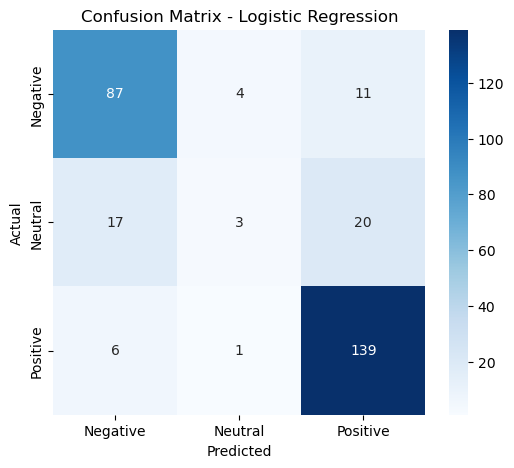

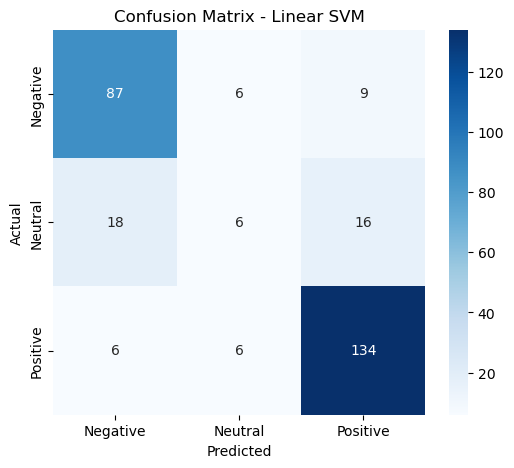

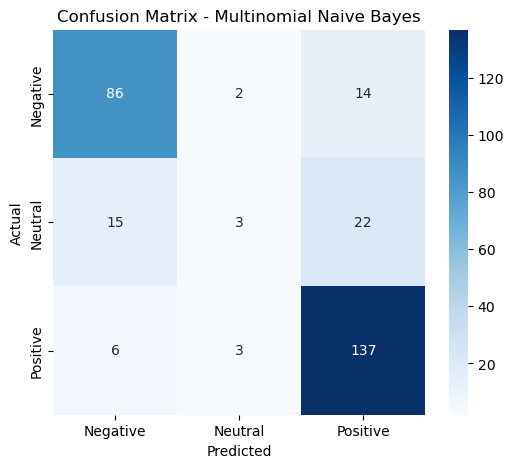

In [252]:
# ============================================
# 26. CONFUSION MATRICES
# ============================================

for model_name, model in models.items():
    
    predictions = model.predict(X_test)
    
    cm = confusion_matrix(
        y_test,
        predictions,
        labels=[
            "negative",
            "neutral",
            "positive"
        ]
    )
    
    plt.figure(figsize=(6, 5))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Negative",
            "Neutral",
            "Positive"
        ],
        yticklabels=[
            "Negative",
            "Neutral",
            "Positive"
        ]
    )
    
    plt.title(
        f"Confusion Matrix - {model_name}"
    )
    
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.show()

In [253]:
# ============================================
# 27. SELECT FINAL MODEL
# ============================================

best_model_name = model_results.iloc[0]["Model"]

print("Selected model based on CV Macro F1:")
print(best_model_name)

Selected model based on CV Macro F1:
Linear SVM


In [254]:
best_models = {
    "Logistic Regression": logreg_grid.best_estimator_,
    "Linear SVM": svm_grid.best_estimator_,
    "Multinomial Naive Bayes": nb_grid.best_estimator_
}

selected_model = best_models[best_model_name]

print(selected_model)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('classifier', LinearSVC(C=10, random_state=42))])


In [255]:
# ============================================
# 28. FINAL MODEL EVALUATION
# ============================================

final_predictions = selected_model.predict(X_test)

print(
    "Final Model:",
    best_model_name
)

print(
    "\nTest Accuracy:",
    accuracy_score(
        y_test,
        final_predictions
    )
)

print(
    "\nTest Macro F1:",
    f1_score(
        y_test,
        final_predictions,
        average="macro"
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        final_predictions,
        labels=[
            "negative",
            "neutral",
            "positive"
        ]
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        final_predictions,
        labels=[
            "negative",
            "neutral",
            "positive"
        ]
    )
)

Final Model: Linear SVM

Test Accuracy: 0.7881944444444444

Test Macro F1: 0.6341621615883354

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.85      0.82       102
     neutral       0.33      0.15      0.21        40
    positive       0.84      0.92      0.88       146

    accuracy                           0.79       288
   macro avg       0.65      0.64      0.63       288
weighted avg       0.75      0.79      0.76       288


Confusion Matrix:
[[ 87   6   9]
 [ 18   6  16]
 [  6   6 134]]


In [256]:
# ============================================
# 29. ERROR ANALYSIS
# ============================================

error_df = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": final_predictions
})

errors = error_df[
    error_df["actual"] != error_df["predicted"]
].copy()

print("Number of errors:", len(errors))

display(
    errors.head(30)
)

Number of errors: 61


,text,actual,predicted
173,was not expecting this..... what would you exp...,neutral,positive
402,budget mobile ! model : samsung m12 6gb ram 12...,positive,neutral
1003,just a android phone. not a smart phone. delay...,negative,neutral
605,phone is heavy and camera quality not good pho...,neutral,negative
1120,samsung forcing me to use their app and i can’...,neutral,negative
239,good phone but performance is not smooth i lik...,neutral,positive
234,just ok for a budget phone not made in china p...,neutral,negative
252,not as good as advertised - my contact book is...,negative,positive
1206,everything is good but not the selfie camera. ...,neutral,positive
277,budgeted phone ever its a budgeted phone. 6 gb...,neutral,positive


In [257]:
# ============================================
# 30. FINAL DEPLOYMENT MODEL
# ============================================

deployment_model = best_models[best_model_name]

deployment_model.fit(
    X,
    y
)

print("Final deployment model trained on all labeled data.")

Final deployment model trained on all labeled data.


In [258]:
# ============================================
# 31. SAVE MODEL
# ============================================

joblib.dump(
    deployment_model,
    "sentiment_pipeline.joblib"
)

print(
    "Saved as sentiment_pipeline.joblib"
)

Saved as sentiment_pipeline.joblib


In [259]:
# ============================================
# 32. TEST SAVED PIPELINE
# ============================================

loaded_model = joblib.load(
    "sentiment_pipeline.joblib"
)

test_reviews = [
    "Excellent phone, battery life is amazing",
    "The product is okay. It works as expected but nothing special.",
    "Very bad camera and the phone hangs frequently"
]

predictions = loaded_model.predict(
    test_reviews
)

for review, prediction in zip(
    test_reviews,
    predictions
):
    
    print("Review:", review)
    print("Prediction:", prediction)
    print("-" * 60)

Review: Excellent phone, battery life is amazing
Prediction: positive
------------------------------------------------------------
Review: The product is okay. It works as expected but nothing special.
Prediction: positive
------------------------------------------------------------
Review: Very bad camera and the phone hangs frequently
Prediction: negative
------------------------------------------------------------
